# Week 6 (Tree-based Models)

## 2.1. Decision Tree

In [1]:
import os
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import graphviz
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn import datasets
from sklearn.model_selection import train_test_split

In [2]:
# 데이터 로드 및 전처리
iris = datasets.load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# 훈련/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

### Q1.1 max_depth 파라미터를 변경하면 트리의 구조와 성능이 어떻게 변할까요?

# A1.1 
max_depth가 너무 작으면 클래수 수만큼 분할이 없어 과소적합이 보인다.

적정수준(2~3)에서 급격히 성능이 오르고, 그 이상은 성능 향상이 거의 없음.

max_depth를 계속 키워도 성능이 그대로인 건 트리가 min_samples_leaf 제약으로 이미 자연스러운 최대 크기에 도달했기 때문

또한 구조는 깊이가 깊어질수록 가지가 많아지고 복잡해진다

In [4]:
# 결정 트리 모델 생성 및 학습
tree_model = DecisionTreeClassifier(criterion="gini", max_depth=3, min_samples_leaf=2, random_state=42)
tree_model.fit(X_train, y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [5]:
for depth in [1, 2, 3, 5, None]:
    m = DecisionTreeClassifier(criterion="gini", max_depth=depth, min_samples_leaf=2, random_state=42)
    m.fit(X_train, y_train)
    print(f"max_depth={depth}: n_leaves={m.get_n_leaves()}, depth={m.get_depth()}, "
          f"train_acc={m.score(X_train, y_train):.3f}, test_acc={m.score(X_test, y_test):.3f}")


max_depth=1: n_leaves=2, depth=1, train_acc=0.675, test_acc=0.633
max_depth=2: n_leaves=3, depth=2, train_acc=0.950, test_acc=0.967
max_depth=3: n_leaves=5, depth=3, train_acc=0.950, test_acc=1.000
max_depth=5: n_leaves=8, depth=5, train_acc=0.975, test_acc=1.000
max_depth=None: n_leaves=8, depth=5, train_acc=0.975, test_acc=1.000


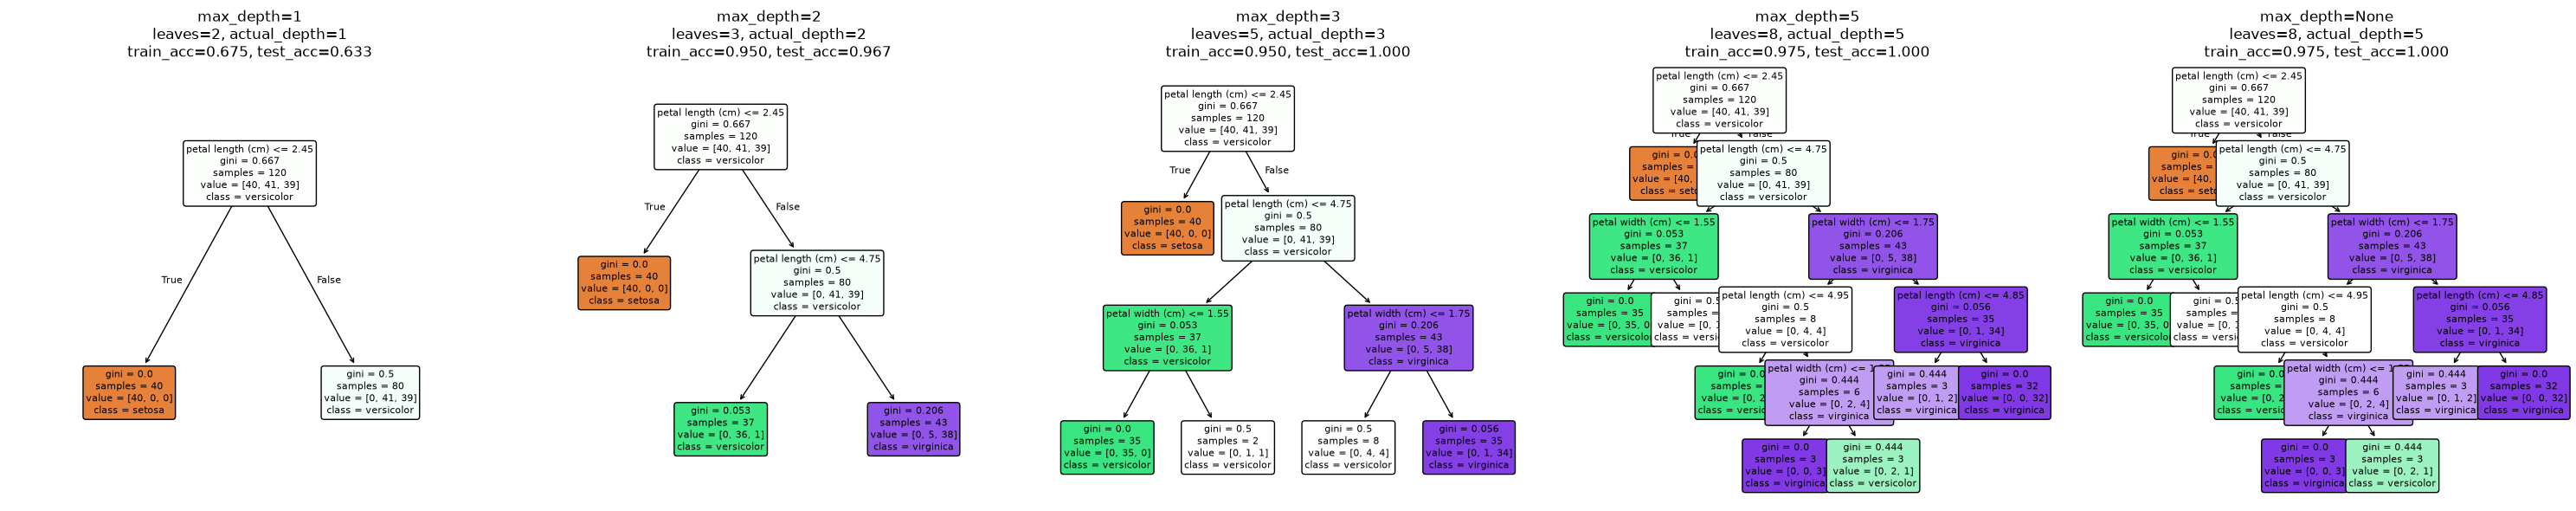

In [6]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

depths = [1, 2, 3, 5, None]

fig, axes = plt.subplots(1, len(depths), figsize=(6 * len(depths), 6))

for ax, depth in zip(axes, depths):
    m = DecisionTreeClassifier(criterion="gini", max_depth=depth, min_samples_leaf=2, random_state=42)
    m.fit(X_train, y_train)

    train_acc = m.score(X_train, y_train)
    test_acc = m.score(X_test, y_test)

    plot_tree(m, feature_names=X.columns, class_names=iris.target_names,
              filled=True, rounded=True, fontsize=8, ax=ax)
    ax.set_title(f"max_depth={depth}\nleaves={m.get_n_leaves()}, actual_depth={m.get_depth()}\n"
                 f"train_acc={train_acc:.3f}, test_acc={test_acc:.3f}")

plt.tight_layout()
plt.show()




### Q1.2 'gini'와 'entropy' 기준의 차이는 무엇이며, 결과에 어떤 영향을 미칠까요?

# A1.2 

## 차이점
1. 계산 비용: Gini는 로그 연산이 없어서 로그 계산이 들어가는 entropy보다 상대적으로 빠르다.

2. 두 지표 모두 노드가 완전히 순수하면 0, 클래스가 균등하면 최대값을 가지는 건 같으나, entropy가 클래스 불균형에 조금 더 민감하게 반응한다.

보통 실무적으로는 둘의 차이가 거의 없다고 한다. iris 처럼 클랫그가 잘 분리되는 쉬운 데이터셋이면 두 기준으로 학습해도 트리 구조와 성능이 거의 동일하게 나올 것이다.

### Q1.3 각 노드의 분할 기준 어떻게 되는지 설명해보세요.

# A1.3

분할 기준 자체는 매번 어떤 피처의 어떤 임계값을 기준으로 나눌 때 지니 불순도가 가장 많이 줄어드는가로 정해진다. 각 노드에서 가능한 모든 조합을 시도해보고, 자식 노드들의 가중평균 gini가 가장 낮아지는 조합을 고른다.

이 트리는 petal length로 크게 나누고, petal width로 세밀하게 보정하는 구조이며, sepal length/width는 feature_importances에서 0이었던 것처럼 이 트리 어디에서도 분할 기준으로 전혀 쓰이지 않았다.

In [13]:
# 트리 시각화 (Graphviz)
dot_data = export_graphviz(
    tree_model,
    out_file=None,
    feature_names=X.columns,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    special_characters=True
)

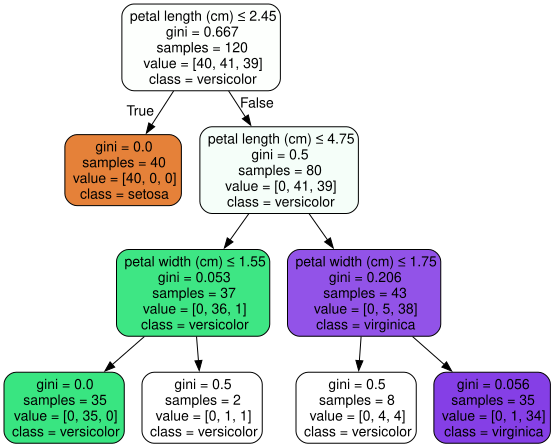

In [8]:
# 그래프 출력
graph = graphviz.Source(dot_data)
graph

## 3. 앙상블 학습: 부스팅(Boosting) 모델

Adaboost, Gradient Boosting Model은 scikit learn에서 지원하지만, LightGBM과 XGBoost의 경우는 외부 패키지를 불러와야 합니다.

Boosting 계열의 모델들은 데이터 개수가 적으면 overfitting이 일어나는 경우가 많으니, 주의해야 합니다.

In [9]:
# 필요한 패키지 로드
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error

housing = fetch_california_housing()

In [10]:
# 데이터 로드
housing_df = pd.DataFrame(housing.data, columns=housing.feature_names)
housing_df['MedHouseVal'] = housing.target

In [11]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Q3.1 `housing_df`를 train, test split을 해봅시다.

분할 비율을 자유롭게 설정해봅시다.

In [15]:
# 데이터 분할
X = housing_df.drop(columns=['MedHouseVal'])
y = housing_df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Q3.2  데이터를 `RandomForestRegressor`에 적합해 봅시다.
train set 에 대해 `MedHouseVal`을 종속변수, 나머지를 독립변수로 하는 random forest regressor를 적합해 봅시다.

test set으로 prediction을 한 후 MSE를 구해 봅시다.

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"RandomForestRegressor MSE: {mse:.4f}")


RandomForestRegressor MSE: 0.2560


### Q3.3 데이터를 `AdaBoostRegressor`에 적합해봅시다.

위와 동일

In [18]:
from sklearn.ensemble import AdaBoostRegressor

ada_model = AdaBoostRegressor(random_state=42)
ada_model.fit(X_train, y_train)

y_pred = ada_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"AdaBoostRegressor MSE: {mse:.4f}")

AdaBoostRegressor MSE: 0.6145


### Q3.4 데이터를 `GradientBoostingRegressor`에 적합해 봅시다.

위와 동일

In [19]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

y_pred = gb_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"GradientBoostingRegressor MSE: {mse:.4f}")

GradientBoostingRegressor MSE: 0.2940


### Q3.5 데이터를 `lightgbm` 회귀에 적합해 봅시다.

파라미터를 자세히 살펴보고, 자유롭게 설정해 봅시다.

Documentation
https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html

예시
https://www.geeksforgeeks.org/regression-using-lightgbm/


In [20]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(random_state=42)
lgb_model.fit(X_train, y_train)


y_pred = lgb_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"LGBMRegressor MSE: {mse:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001597 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.071947
LGBMRegressor MSE: 0.2148


### Q3.6 데이터를 `xgboost`에 적합해 봅시다.

파라미터는 자유롭게 설정해 봅시다

In [21]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"XGBRegressor MSE: {mse:.4f}")

XGBRegressor MSE: 0.2226


### Q3.7 `RandomForestRegressor`의 feature importance를 시각화해봅시다.

https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html

위를 참고해보면서 Q2에서 적합한 random forest regressor의 feature importance를 시각화해 봅시다.

중요한 feature 부터 내림차순으로 시각화해 봅시다.

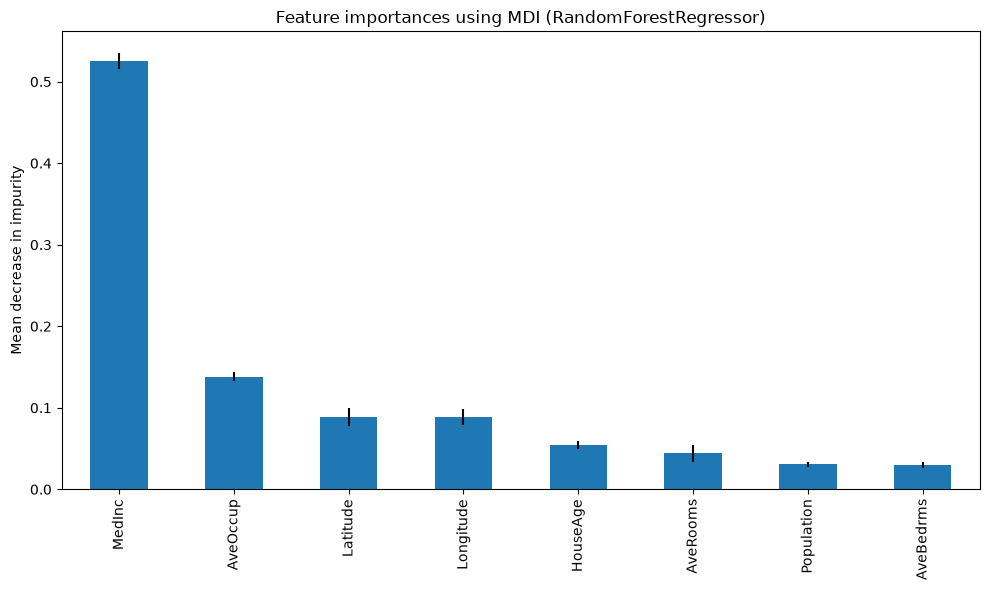

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
std = np.std([tree.feature_importances_ for tree in rf_model.estimators_], axis=0)

importances_sorted = importances.sort_values(ascending=False)
std_sorted = pd.Series(std, index=X_train.columns).loc[importances_sorted.index]

fig, ax = plt.subplots(figsize=(10, 6))
importances_sorted.plot.bar(yerr=std_sorted, ax=ax)
ax.set_title("Feature importances using MDI (RandomForestRegressor)")
ax.set_ylabel("Mean decrease in impurity")
plt.tight_layout()
plt.show()

### (BONUS) 1. Boosting 모델 각각의 특징을 정리해보세요.

# BONUS 1

## AdaBoost (MSE: 0.6145, 가장 낮은 성능)
- 이전 모델이 **틀린 샘플에 가중치를 높여가며** 다음 약한 학습기(주로 얕은 트리, stump)를 순차적으로 학습시키는 방식.
- gradient가 아니라 샘플 가중치 재조정 기반이라, 회귀 문제나 feature가 많고 비선형적인 데이터(California housing 등)에서는 상대적으로 약함. 분류 문제, 비교적 단순한 데이터에서 더 강점을 보이는 편.
- 이상치(outlier)에 민감함 — 계속 틀리는 샘플의 가중치가 누적해서 커지기 때문.

## GradientBoosting (MSE: 0.2940)
- 이전 모델의 **잔차(residual)를 다음 트리가 예측**하도록 순차적으로 학습 (gradient descent를 함수 공간에서 수행하는 방식).
- AdaBoost보다 유연하고 일반적으로 성능이 좋지만, **level-wise(depth-wise) 트리 성장 + 트리를 순차적으로만 학습**하기 때문에 학습 속도가 느림.
- 별도의 병렬화·최적화가 없는 sklearn 기본 구현이라, 대용량 데이터에서는 LightGBM/XGBoost 대비 느리고 성능도 다소 떨어짐.

## LightGBM (MSE: 0.2148, 가장 높은 성능)
- **leaf-wise 트리 성장**: 매 스텝마다 전체 리프 중 gain이 가장 큰 리프 하나만 골라서 분할 → 같은 리프 개수 기준으로 level-wise보다 낮은 loss 달성.
- **히스토그램 기반 분할 탐색 + GOSS(gradient 작은 샘플 서브샘플링) + EFB(희소 feature 묶기)**로 학습 속도가 매우 빠름.
- 대신 leaf-wise 특성상 작은 데이터셋에서는 한쪽 가지만 깊어지며 과적합하기 쉬움 → `num_leaves`, `min_child_samples`로 규제 필요.
- 오늘 실험(California housing, 2만 행)처럼 표본이 충분하고 feature가 많은 데이터에서 강점을 보임.

## XGBoost (MSE: 0.2226)
- GradientBoosting과 같은 잔차 학습 계열이지만, **2차 미분(Hessian)까지 활용한 뉴턴 방식 최적화**, **L1/L2 정규화**가 기본 내장되어 있어 과적합에 더 강건함.
- 기본은 level-wise 성장이지만 `tree_method="hist"`, `grow_policy="lossguide"`로 설정하면 LightGBM과 유사한 leaf-wise 방식도 지원.
- 병렬 처리·결측치 자동 처리 등 실무 편의 기능이 많아, LightGBM과 성능이 근접하면서도 널리 쓰임 (오늘 결과에서도 LightGBM과 큰 차이 없음).

## 공통 정리
Boosting 계열은 트리를 순차적으로 쌓아 이전 모델의 오차를 보완하는 방식이라, Random Forest(병렬·독립적 트리 평균)보다 편향(bias)을 줄이는 데 유리하지만 **데이터가 적거나 학습을 오래 시키면 과적합 위험이 크다**. LightGBM/XGBoost가 AdaBoost/GradientBoosting보다 대체로 나은 성능을 보이는 건, 더 정교한 트리 성장 전략과 정규화 기법이 추가되었기 때문이다.

### (BONUS) 2. 모델 성능을 높이기 위하여 어떤 시도를 하면 좋을지 고민해보세요.

# BONUS 2

## 1. 하이퍼파라미터 튜닝
- 지금은 전부 `random_state`만 고정한 기본값으로 학습했음. `GridSearchCV`/`RandomizedSearchCV`(또는 Optuna) + 교차검증(K-Fold)으로 `n_estimators`, `max_depth`(또는 LightGBM은 `num_leaves`), `learning_rate`, `min_child_samples` 등을 탐색하면 대부분 지금보다 MSE가 낮아질 것으로 예상됨.
- 특히 boosting 계열은 `learning_rate`를 낮추고 `n_estimators`를 늘리는 조합(작은 보폭으로 많이 학습)이 보통 더 안정적인 성능을 냄.

## 2. Early stopping
- 학습용 데이터를 다시 train/validation으로 나눠서, validation loss가 더 이상 개선되지 않으면 학습을 멈추는 방식(`early_stopping_rounds` 등). 불필요하게 많은 트리를 쌓아 과적합하는 걸 방지하면서, 최적의 `n_estimators`를 자동으로 찾을 수 있음.

## 3. Feature engineering
- Q3.7에서 확인했듯 `MedInc`(중위소득)의 importance가 압도적으로 높고, `Latitude`/`Longitude`는 개별로는 중간 수준의 중요도였음. 위도·경도를 그대로 쓰기보다 **주요 도시(LA, SF 등)까지의 거리**로 변환하거나, 위경도를 클러스터링(KMeans)해서 지역 카테고리로 만들면 더 유의미한 신호가 될 수 있음.
- `AveRooms`, `AveBedrms`, `Population`, `AveOccup`처럼 분포가 한쪽으로 치우친(skewed) feature는 로그 변환을 고려.

## 4. 이상치/데이터 품질 점검
- California housing 데이터는 `MedHouseVal`이 5.0에서 클리핑(censoring)되어 있는 것으로 알려져 있음 — 이런 상한값에 몰린 샘플들을 제외하거나 별도 처리하면 회귀 성능이 개선될 수 있음.

## 5. 모델 앙상블(스태킹/블렌딩)
- RandomForest, LightGBM, XGBoost처럼 편향(bias) 구조가 다른 모델들의 예측을 평균 내거나, 메타 모델로 스태킹하면 개별 모델보다 더 낮은 MSE를 얻을 가능성이 높음.

## 6. 평가 방식 보강
- 지금은 단일 train/test split(test_size=0.2)으로만 평가했는데, K-Fold 교차검증으로 여러 split에 대한 평균 MSE를 보면 특정 분할에 운 좋게/나쁘게 걸린 효과를 줄이고 더 신뢰도 높은 비교가 가능함.